# Augmenting with Noise Textures

Notebook 00_characterizing_noise_augmentation.ipynb

## Introduction: Deep Learning Denoising
Deep convolutional neural networks (CNNs) have been shown to be effective for [CT denoising applications](https://pubs.rsna.org/doi/abs/10.1148/rg.2021200196) as powerful tools for removing noise from CT images and are already being used clinically, both in vendor specific implementations:

| Product          | 510(k) Summary | Assessment | Type | Vendor Specific|
|------------------|:----------:|----------------|------|----------------|
| [Canon AiCE](https://global.medical.canon/products/computed-tomography/aice)|[K192832](https://www.accessdata.fda.gov/cdrh_docs/pdf19/K192832.pdf)|[Brady et al 2021](https://pubs.rsna.org/doi/full/10.1148/radiol.2020202317)|Image Based|Yes|
| [GE True Fidelity DLIR](https://www.gehealthcare.com/products/truefidelity)|[K201745](https://www.accessdata.fda.gov/cdrh_docs/pdf20/K201745.pdf)|[Noda et al 2021](https://doi.org/10.1007/s00261-021-03111-x)| Image Based     | Yes |
| United Imaging Deep Recon| [K193073](https://www.accessdata.fda.gov/cdrh_docs/pdf19/K193073.pdf) | | Image Based | Yes |
| [Philips Precise Image](https://www.philips.com/c-dam/b2bhc/master/resource-catalog/landing/precise-suite/incisive_precise_image.pdf) | [K210760](https://www.accessdata.fda.gov/cdrh_docs/pdf21/K210760.pdf) | | Image Based | Yes |
| [Claripi ClariCT](https://www.claripi.com/clarict-ai/)      | [K183460](https://www.accessdata.fda.gov/cdrh_docs/pdf18/K183460.pdf)|  | Image Based | No |

### Deep Learning Denoisers Learn Image Textures
However, despite deep learning's flexibility to learn challenging computer vision tasks from data, these models are known to not generalize well to data characteristically different than they were trained on. This was shown by a deep learning pneumonia detection model that performed well on internal data, more similar to its training set, than on external data where performance droped [Zech et al., 2018](https://journals.plos.org/plosmedicine/article?id=10.1371/journal.pmed.1002683). Specifically, deep denoising algorithms - often based on deep recurrent layers of convolutions (See [Chen et al 2017]()) - have been shown learn specific frequencies of noise texture via training. [Zeng et al 2022](http://onlinelibrary.wiley.com/doi/abs/10.1002/mp.15430) showed this by testing deep denoisers on sharp kernel test sets after training the models on smooth kernel training data. The noise power spectra of the denoised images revealed that only noise power in the lower spatial frequencies encountered in the training data were removed, leaving the higer frequencies largely untouched.

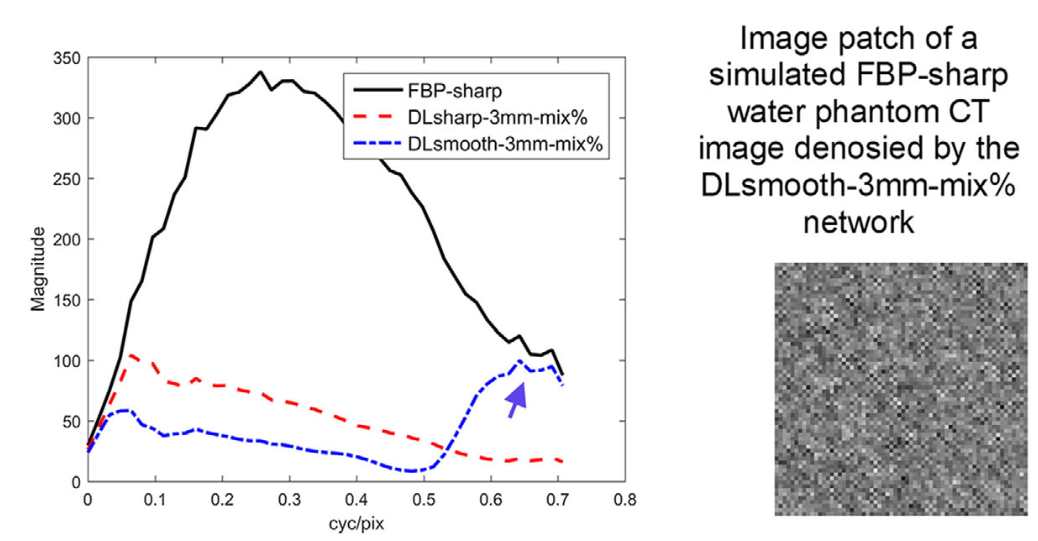

From Figure 8 of [Zeng et al 2022](http://onlinelibrary.wiley.com/doi/abs/10.1002/mp.15430)

### Impact on Pediatric Populations

See also [ITK's discussion of Data Augmentation for Machine Learning](https://insightsoftwareconsortium.github.io/SimpleITK-Notebooks/Python_html/70_Data_Augmentation.html)
- to be sure that we are helping rather than hurting we need to ensure that our augmentations are representative of the natural variability in our intended population, here pediatric patients.

## Aims

**In this notebook** we will do this in two ways:
1. [study the noise power spectra of pediatric patient images, generated via simulation using the XCAT phantoms](#Noise-Texture-from-Pediatric-CT-Simulations)
2. [assess whether this noise power can be reproduced by equal sized water phantoms](#Noise-Texture-from-Pediatric-Sized-Water-Phantom-Simulations)
    - This second step is of practical importance as being able to make these experiments using physical phantoms is an important consideration for making these conclusions usable in the real world where we cannot peform multiple acquisitions on patients.

## Switch to PediatricIQphantoms dataset

Since I only use 2 dose levels in the paper 25 and 100, I can use that data to make this code/paper more reproducible

So switch over to dicom reading

May need to supplement some of the physical and xcat data

If reproducing these figures on your own local dataset, replace `peds_datadir` with your download location of the dataset available for download at [Zenodo](https://zenodo.org/doi/10.5281/zenodo.10064035)

[![DOI](https://zenodo.org/badge/DOI/10.5281/zenodo.11267694.svg)](https://doi.org/10.5281/zenodo.11267694)

These phantom simulations were generated using the [pediatricIQphantoms](https://github.com/DIDSR/pediatricIQphantoms), please see the associated [documentation](https://pediatriciqphantoms.readthedocs.io/en/latest/?badge=latest) on how to rerun the simulations under different imaging conditions.

These figures also require the [Mayo Clinic Low Dose Grand Challenge Dataset](https://ctcicblog.mayo.edu/patient-ct-projection-data-library/)  - download site: <https://doi.org/10.7937/9npb-2637.>

## Noise Texture from Pediatric CT Simulations

We hypothesize that noise textures are a key difference between adult and pediatric protocols that cause deep learning denoisers to degrade performance when only trained on adult data. The key cause is that noise textures from the smaller field of view pediatric protocols are absent from the adult training data, we aim to demonstrate that here in this section. In the [following section](#Noise-Texture-from-Pediatric-Sized-Water-Phantom-Simulations) we will that this noise textures can be reproduced in phantom scans and integrated into model training via [data augmentation](#Data-Augmentation-with-Pediatric-Protocol-Noise-Patches).

Let's first look at the noise texture from a common dataset for developing and evaluating CT denoising frameworks, the [Mayo Clinic Low Dose Grand Challenge Dataset](https://ctcicblog.mayo.edu/patient-ct-projection-data-library/)

Here is the download [link](https://aapm.app.box.com/s/eaw4jddb53keg1bptavvvd1sf4x3pe9h/folder/145241244881), in this study we are using the 1 mm D45 sharp kernels, low full and quarter dose sets:

In [1]:
from pathlib import Path
from dotenv import load_dotenv
import os

load_dotenv()

ldgc_path = Path(os.environ['LDGC_PATH']) # training dataset
peds_datadir = Path(os.environ['PEDIATRICIQ_PATH']) # testing dataset
anthro_datadir = Path(os.environ['ANTHROPOMORPHIC_PATH']) # testing dataset

ldgc_path.exists(), peds_datadir.exists(), anthro_datadir.exists()

(True, True, True)

In [2]:
if not ldgc_path.exists():
    raise RuntimeError(f'Low Dose Grand Challenge Dataset not found in {ldgc_path}, please download here: <https://aapm.app.box.com/s/eaw4jddb53keg1bptavvvd1sf4x3pe9h/folder/145241244881>')

from torchvision.datasets.utils import download_and_extract_archive
if not peds_datadir.exists():
    download_and_extract_archive(url='https://zenodo.org/records/11267694/files/pediatricIQphantoms.zip', download_root=peds_datadir.parent)

if not anthro_datadir.exists():
    download_and_extract_archive(url='https://zenodo.org/records/12538350/files/anthropomorphic.zip?download=1', download_root=anthro_datadir.parent)

In [3]:
import pandas as pd
experiment_dir = Path('/home/brandon.nelson/Dev/pediatric-CT-noise-texture-augmentation/denoising/lightning_logs/2025-03-05_19-45_augmented_hist')
meta = pd.read_csv(experiment_dir / 'metadata.csv')
# meta.file = meta.file.apply(lambda o: peds_datadir.parent / o.split('../data/')[1])
meta

,name,effective diameter [cm],age [year],pediatric subgroup,phantom,scanner,Dose [%],recon,kernel,FOV [cm],...,gender,weight [kg],height [cm],BMI,weight percentile,ethnicity,simulated,instance,slice,lambda
0,11.2 cm CTP404,11.2,0.083333,newborn,CTP404,Siemens Somatom Definition,25.0,fbp,D45,12.30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
1,11.2 cm CTP404,11.2,0.083333,newborn,CTP404,Siemens Somatom Definition,25.0,fbp,D45,12.30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.0
2,11.2 cm CTP404,11.2,0.083333,newborn,CTP404,Siemens Somatom Definition,25.0,fbp,D45,12.30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,0.0
3,11.2 cm CTP404,11.2,0.083333,newborn,CTP404,Siemens Somatom Definition,25.0,fbp,D45,12.30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,0.0
4,11.2 cm CTP404,11.2,0.083333,newborn,CTP404,Siemens Somatom Definition,25.0,fbp,D45,12.30,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103003,female pt151,28.1,66.000000,adolescent,anthropomorphic,Siemens Definition AS+ (simulated),25.0,train_adult_augmented_0.4_UNet_1,D45,36.53,...,F,66.4,162.0,25.301021,48.8,white,True,5.0,5.0,0.4
103004,female pt151,28.1,66.000000,adolescent,anthropomorphic,Siemens Definition AS+ (simulated),25.0,train_adult_augmented_0.4_UNet_1,D45,36.53,...,F,66.4,162.0,25.301021,48.8,white,True,6.0,6.0,0.4
103005,female pt151,28.1,66.000000,adolescent,anthropomorphic,Siemens Definition AS+ (simulated),25.0,train_adult_augmented_0.4_UNet_1,D45,36.53,...,F,66.4,162.0,25.301021,48.8,white,True,7.0,7.0,0.4
103006,female pt151,28.1,66.000000,adolescent,anthropomorphic,Siemens Definition AS+ (simulated),25.0,train_adult_augmented_0.4_UNet_1,D45,36.53,...,F,66.4,162.0,25.301021,48.8,white,True,8.0,8.0,0.4


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import sys
sys.path.append('../denoising')

from utils import ctshow, load_img

Look at representative patchesnoise pasnoise in CT
 imnon-stationy, so by sampling noise from different parts of the image, central vs peripheral and different azimuthal locations shows differences in noiese textur

In [5]:
from make_noise_patches import plot_representative_noise_patches
# noise_image_dict = make_noise_image_dict(meta, max_images=100)

newborn


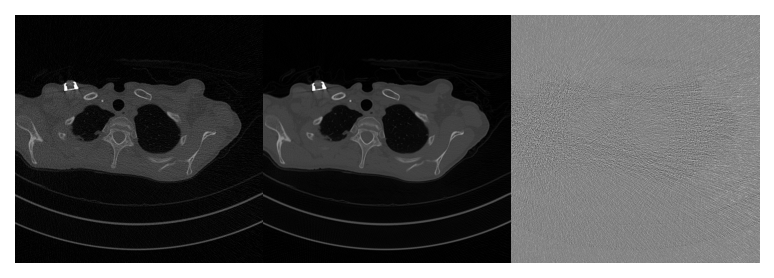

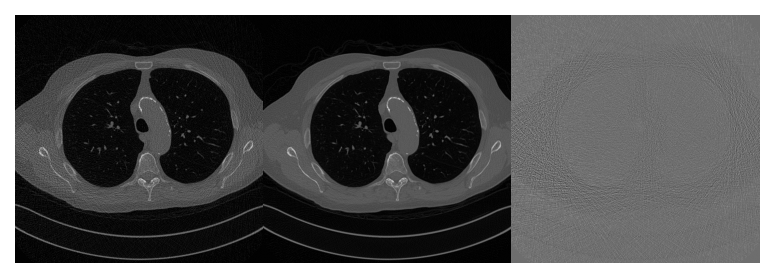

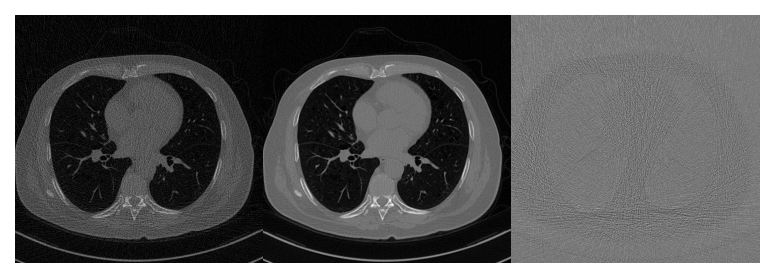

child


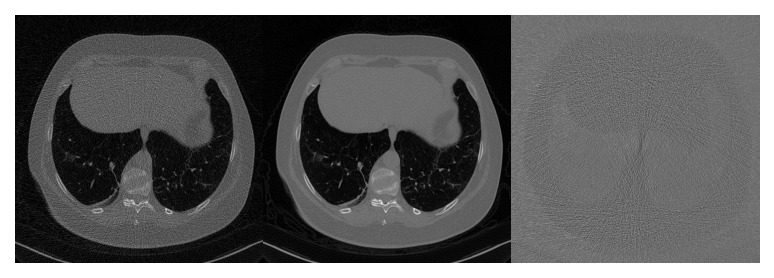

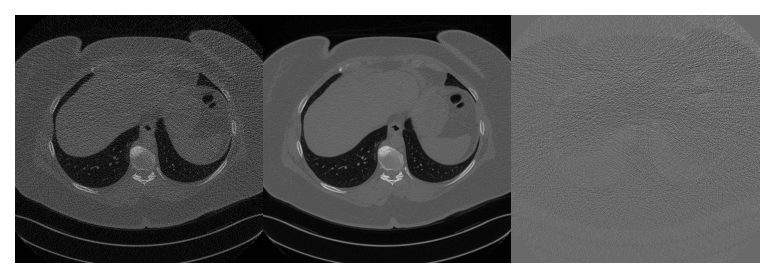

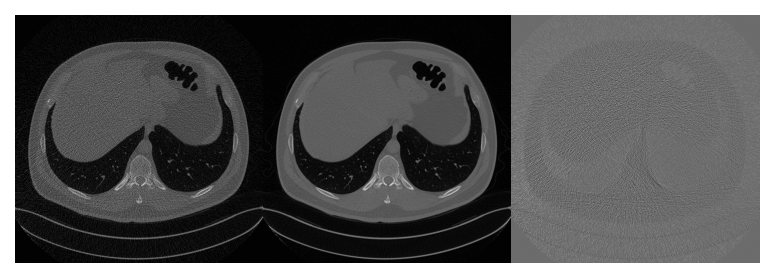

adolescent


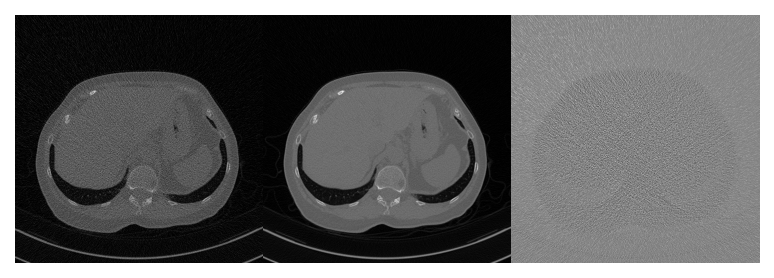

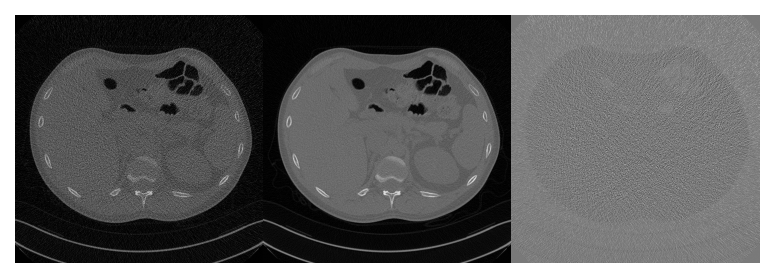

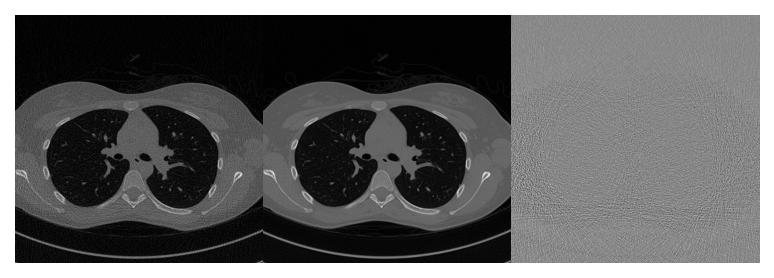

adult


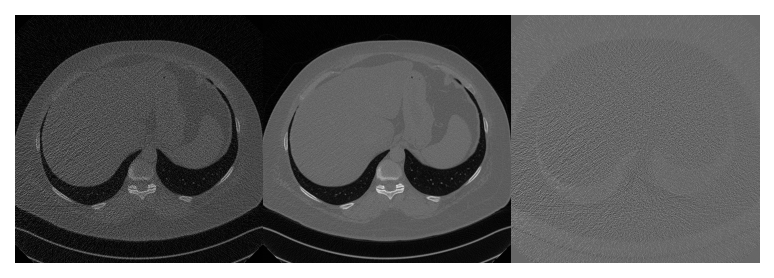

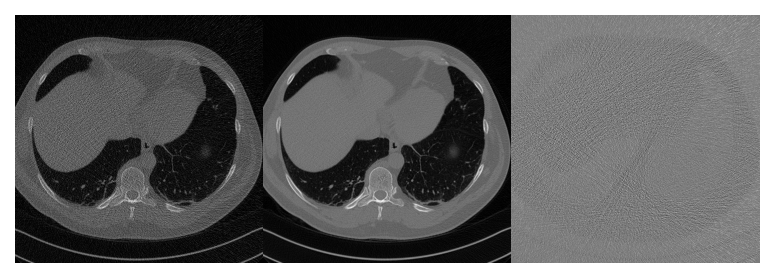

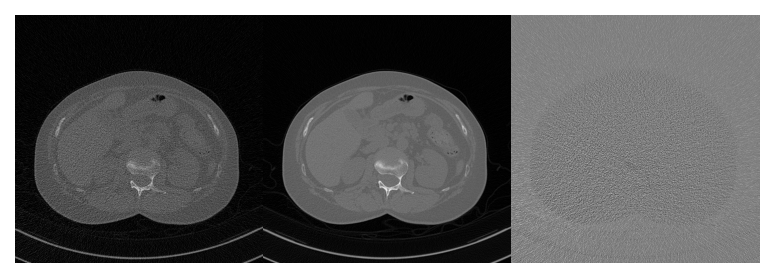

In [6]:
from data import AugmentedDataset, MayoLDGCDataset, PediatricIQDataset
noise_image_dict = dict()
subgroups = ['newborn', 'child', 'adolescent', 'adult']
n_examples = 3

for group in subgroups:
    
    noise_aug = AugmentedDataset(MayoLDGCDataset, dict(root=os.environ['LDGC_PATH'], region='chest'),
                                 PediatricIQDataset, dict(root=os.environ['PEDIATRICIQ_PATH'],
                                                     phantom='uniform', subgroup=group), proportion=0)

    imgs = []
    print(group)
    for _ in range(n_examples):
        idx = np.random.randint(0, len(noise_aug))
        x, y = noise_aug[idx]
        f, axs = plt.subplots(1, 3, gridspec_kw=dict(wspace=0, hspace=0), dpi=150)
        [ax.set_axis_off() for ax in axs]
        axs[0].imshow(x, cmap='gray')
        axs[1].imshow(y, cmap='gray')
        axs[2].imshow(x-y, cmap='gray')
        plt.show()

In [7]:
from data import AugmentedDataset, MayoLDGCDataset, PediatricIQDataset
noise_image_dict = dict()
subgroups = ['newborn', 'child', 'adolescent', 'adult']
n_examples = 10
for group in subgroups:
    noise_aug = AugmentedDataset(MayoLDGCDataset, dict(root=os.environ['LDGC_PATH'], region='abdomen'),
                                 PediatricIQDataset, dict(root=os.environ['PEDIATRICIQ_PATH'],
                                                     phantom='uniform', subgroup=group), proportion=1)
    imgs = []
    for idx in range(n_examples):
        x, y = noise_aug[idx]
        imgs.append(x - y)
    noise_image_dict[group] = np.stack(imgs)

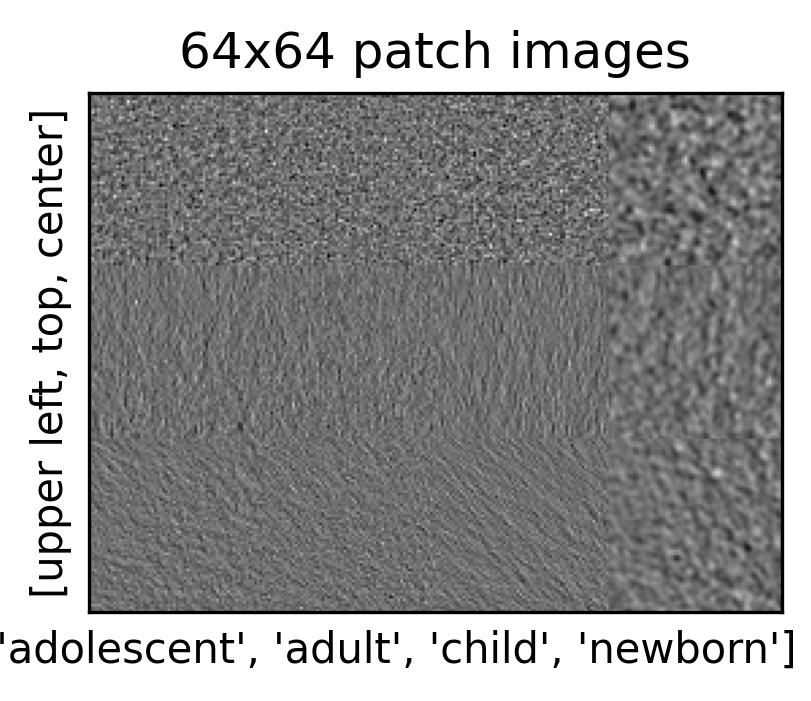

In [8]:
patch_size = 64
diams = subgroups
corner_patches, corners = plot_representative_noise_patches({k: v for k,v in noise_image_dict.items() if k in diams},
                                                            patch_size=patch_size)

In [9]:
corner_patches['child'].keys()

dict_keys([(256, 256), (50, 256), (110, 110)])

Let's grab a corner noise patch from a small FOV scan representative of a peripheral noise patch from a small patient

In [10]:
noise_patch = corner_patches['newborn'][(110, 110)][0]
noise_patch.shape

(64, 64)

In [11]:
from data import AugmentedDataModule
aug_dm = AugmentedDataModule(MayoLDGCDataset, dict(root=os.environ['LDGC_PATH'], region='chest'),
                             PediatricIQDataset, dict(root=os.environ['PEDIATRICIQ_PATH'],
                             phantom='uniform', subgroup=group), proportion=0, patch_size=64, num_workers=1)
aug_dm.setup('fit')
aug_dl = aug_dm.train_dataloader()


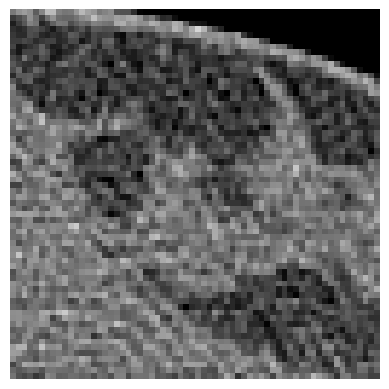

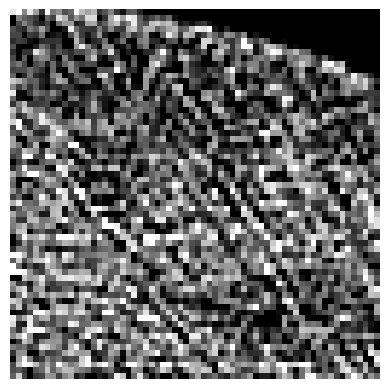

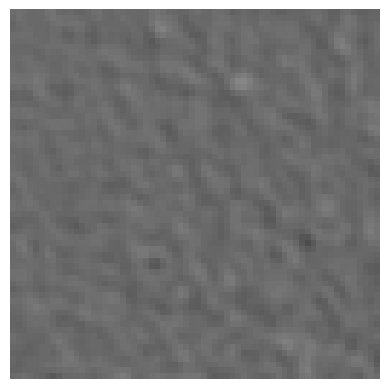

/tmp/ipykernel_2478360/549052463.py:18: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(y[row, col] + noise_patch, cmap='gray', vmin=-250, vmax=350)


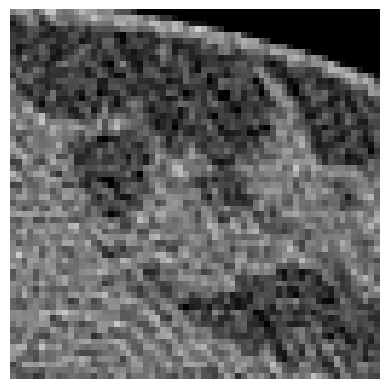

In [12]:
for x, y in aug_dl:
    break

row = 0
col = 0 
plt.imshow(y[row, col], cmap='gray', vmin=-250, vmax=350)
plt.axis('off')
plt.savefig('images/fd_patch.png', dpi=300, bbox_inches='tight')
plt.show()
plt.imshow(x[row, col], cmap='gray', vmin=-250, vmax=350)
plt.axis('off')
plt.savefig('images/qd_patch.png', dpi=300, bbox_inches='tight')
plt.show()
plt.imshow(noise_patch, cmap='gray', vmin=-250, vmax=350)
plt.axis('off')
plt.savefig('images/noise_patch.png', dpi=300, bbox_inches='tight')
plt.show()
plt.imshow(y[row, col] + noise_patch, cmap='gray', vmin=-250, vmax=350)
plt.axis('off')
plt.savefig('images/aug_patch.png', dpi=300, bbox_inches='tight')
plt.show()

## Figure 1

In [18]:
!pwd

/home/brandon.nelson/Dev/pediatric-CT-noise-texture-augmentation/notebooks


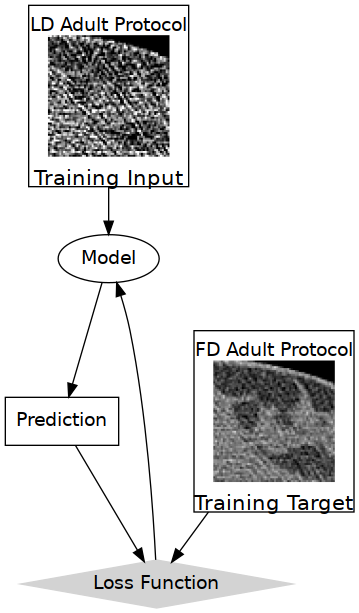

In [20]:
from pathlib import Path
from PIL import Image
import pydot
fname = 'fig1a_traditional'
img_font = 16
img_dir = '/home/brandon.nelson/Dev/pediatric-CT-noise-texture-augmentation/notebooks/images'

'http://magjac.com/graphviz-visual-editor/'
dot_string = f"""digraph dot_image {{
    fontname="Helvetica,Arial,sans-serif"
    node [fontname="Helvetica,Arial,sans-serif"]
    edge [fontname="Helvetica,Arial,sans-serif"]
    layout=dot
    node [shape=box]; {{node [label=<<TABLE border="0" cellborder="0">
                                      <TR><td width="100" height="10" fixedsize="true"><font point-size="{img_font-2}">LD Adult Protocol</font></td></TR>
                                      <TR><TD width="100" height="100" fixedsize="true"><IMG SRC="{img_dir}/qd_patch.png" scale="true"/></TD></TR>
                                      <TR><td width="100" height="10" fixedsize="true"><font point-size="{img_font}">Training Input</font></td></TR>
                                    </TABLE>>] input}};
    node [shape=box]; {{node [label=<<TABLE border="0" cellborder="0">
                                      <TR><td width="100" height="10" fixedsize="true"><font point-size="{img_font-2}">FD Adult Protocol</font></td></TR>
                                      <TR><TD width="100" height="100" fixedsize="true"><IMG SRC="{img_dir}/fd_patch.png" scale="true"/></TD></TR>
                                      <TR><td width="100" height="10" fixedsize="true"><font point-size="{img_font}">Training Target</font></td></TR>
                                    </TABLE>>] target}};
    node [shape=box]; Prediction;

    node [shape=ellipse]; Model;
    node [shape=diamond,style=filled,color=lightgrey]; {{node [label="Loss Function"] loss}};

    input -> Model [len=1.00];

    Model -> Prediction [len=1.00];
    Prediction -> loss [len=1.00];

    target -> loss [len=1.00];
    loss -> Model [len=1.00];

    fontsize=24;
}}"""
fig_dir = Path('figures')
fig_dir.mkdir(exist_ok=True)
(fig_dir / 'for_submission').mkdir(exist_ok=True)
graphs = pydot.graph_from_dot_data(dot_string)[0]
# graphs.write_pdf(fig_dir / f'for_submission/{fname}.pdf')
graphs.write_png(fig_dir / f'{fname}.png')
Image.open(fig_dir / f'{fname}.png')

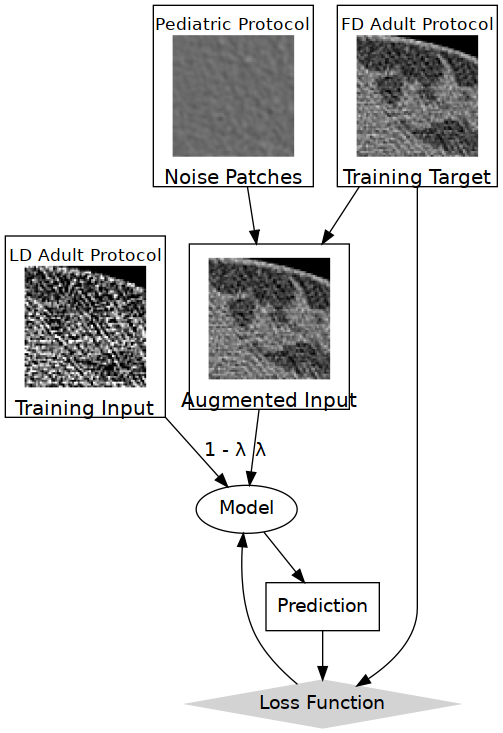

In [21]:
fname = 'fig1b_augmented'
img_font = 15
dot_string = f"""digraph {{
    fontname="Helvetica,Arial,sans-serif"
    node [fontname="Helvetica,Arial,sans-serif"]
    edge [fontname="Helvetica,Arial,sans-serif"]
    layout=dot
    node [shape=box]; {{node [label=<<TABLE border="0" cellborder="0">
                                      <TR><td width="100" height="10" fixedsize="true"><font point-size="{img_font-2}">LD Adult Protocol</font></td></TR>
                                      <TR><TD width="100" height="100" fixedsize="true"><IMG SRC="{img_dir}/qd_patch.png" scale="true"/></TD></TR>
                                      <TR><td width="100" height="10" fixedsize="true"><font point-size="{img_font}">Training Input</font></td></TR>
                                    </TABLE>>] input}};
    node [shape=box]; {{node [label=<<TABLE border="0" cellborder="0">
                                          <TR><td width="100" height="10" fixedsize="true"><font point-size="{img_font-2}">FD Adult Protocol</font></td></TR>
                                      <TR><TD width="100" height="100" fixedsize="true"><IMG SRC="{img_dir}/fd_patch.png" scale="true"/></TD></TR>
                                      <TR><td width="100" height="10" fixedsize="true"><font point-size="{img_font}">Training Target</font></td></TR>
                                    </TABLE>>] target}};
    node [shape=box]; Prediction;
    node [shape=box]; {{node [label=<<TABLE border="0" cellborder="0">
                                      <TR><td width="100" height="10" fixedsize="true"><font point-size="{img_font-2}">Pediatric Protocol</font></td></TR>
                                      <TR><TD width="100" height="100" fixedsize="true"><IMG SRC="{img_dir}/noise_patch.png" scale="true"/></TD></TR>
                                      <TR><td width="100" height="10" fixedsize="true"><font point-size="{img_font}">Noise Patches</font></td></TR>
                                    </TABLE>>] patches}};
    node [shape=box]; {{node [label=<<TABLE border="0" cellborder="0">
                                      <TR><TD width="100" height="100" fixedsize="true"><IMG SRC="{img_dir}/aug_patch.png" scale="true"/></TD></TR>
                                      <TR><td width="100" height="10" fixedsize="true"><font point-size="{img_font}">Augmented Input</font></td></TR>
                                    </TABLE>>] augmented}};

    node [shape=ellipse]; Model;
    node [shape=diamond,style=filled,color=lightgrey]; {{node [label="Loss Function"] loss}};

    patches -> augmented;
    target ->  augmented [len=1.00];

    input -> Model  [label="1 - λ"];
    augmented -> Model  [label="λ"];

    Model -> Prediction [len=1.00];
    Prediction -> loss [len=1.00];
    target -> loss [len=1.00];
    loss -> Model [len=1.00];

    fontsize=24;
}}"""
graphs = pydot.graph_from_dot_data(dot_string)[0]
graphs.write_pdf(f'figures/for_submission/{fname}.pdf')
graphs.write_png(f'figures/{fname}.png')
Image.open(f'figures/{fname}.png')

Next we'll discuss how to make these size-specific noise patches from phantom data. Here's the high-level summary from 
## Figure 2.a.

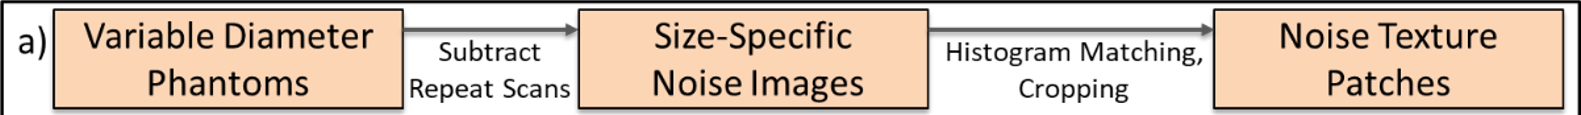

## Figure 2.b.

<Figure size 960x720 with 0 Axes>

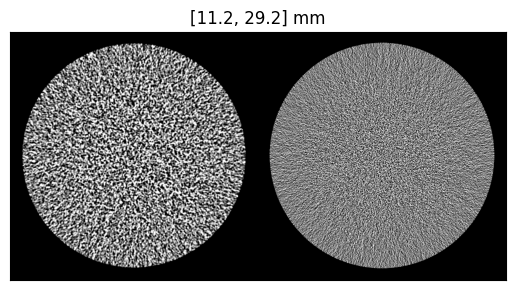

In [27]:
diams = [11.2, 29.2]
plt.figure(dpi=150)
ctshow(np.concatenate([load_img(meta[(meta.recon=='fbp') &
                                     (meta.phantom=='uniform') &
                                     (meta['Dose [%]']==25) &
                                     (meta['effective diameter [cm]']==d)].file.iloc[0]) for d in diams],
                      axis=1), (120, 0))
plt.title(f'{diams} mm')
plt.savefig('figures/fig2b_noise_texture_image_comparison.png', dpi=600)

## Figure 2.c

Below we show for 2 diameters but you can modifiy and add to the `diams` list to explore others

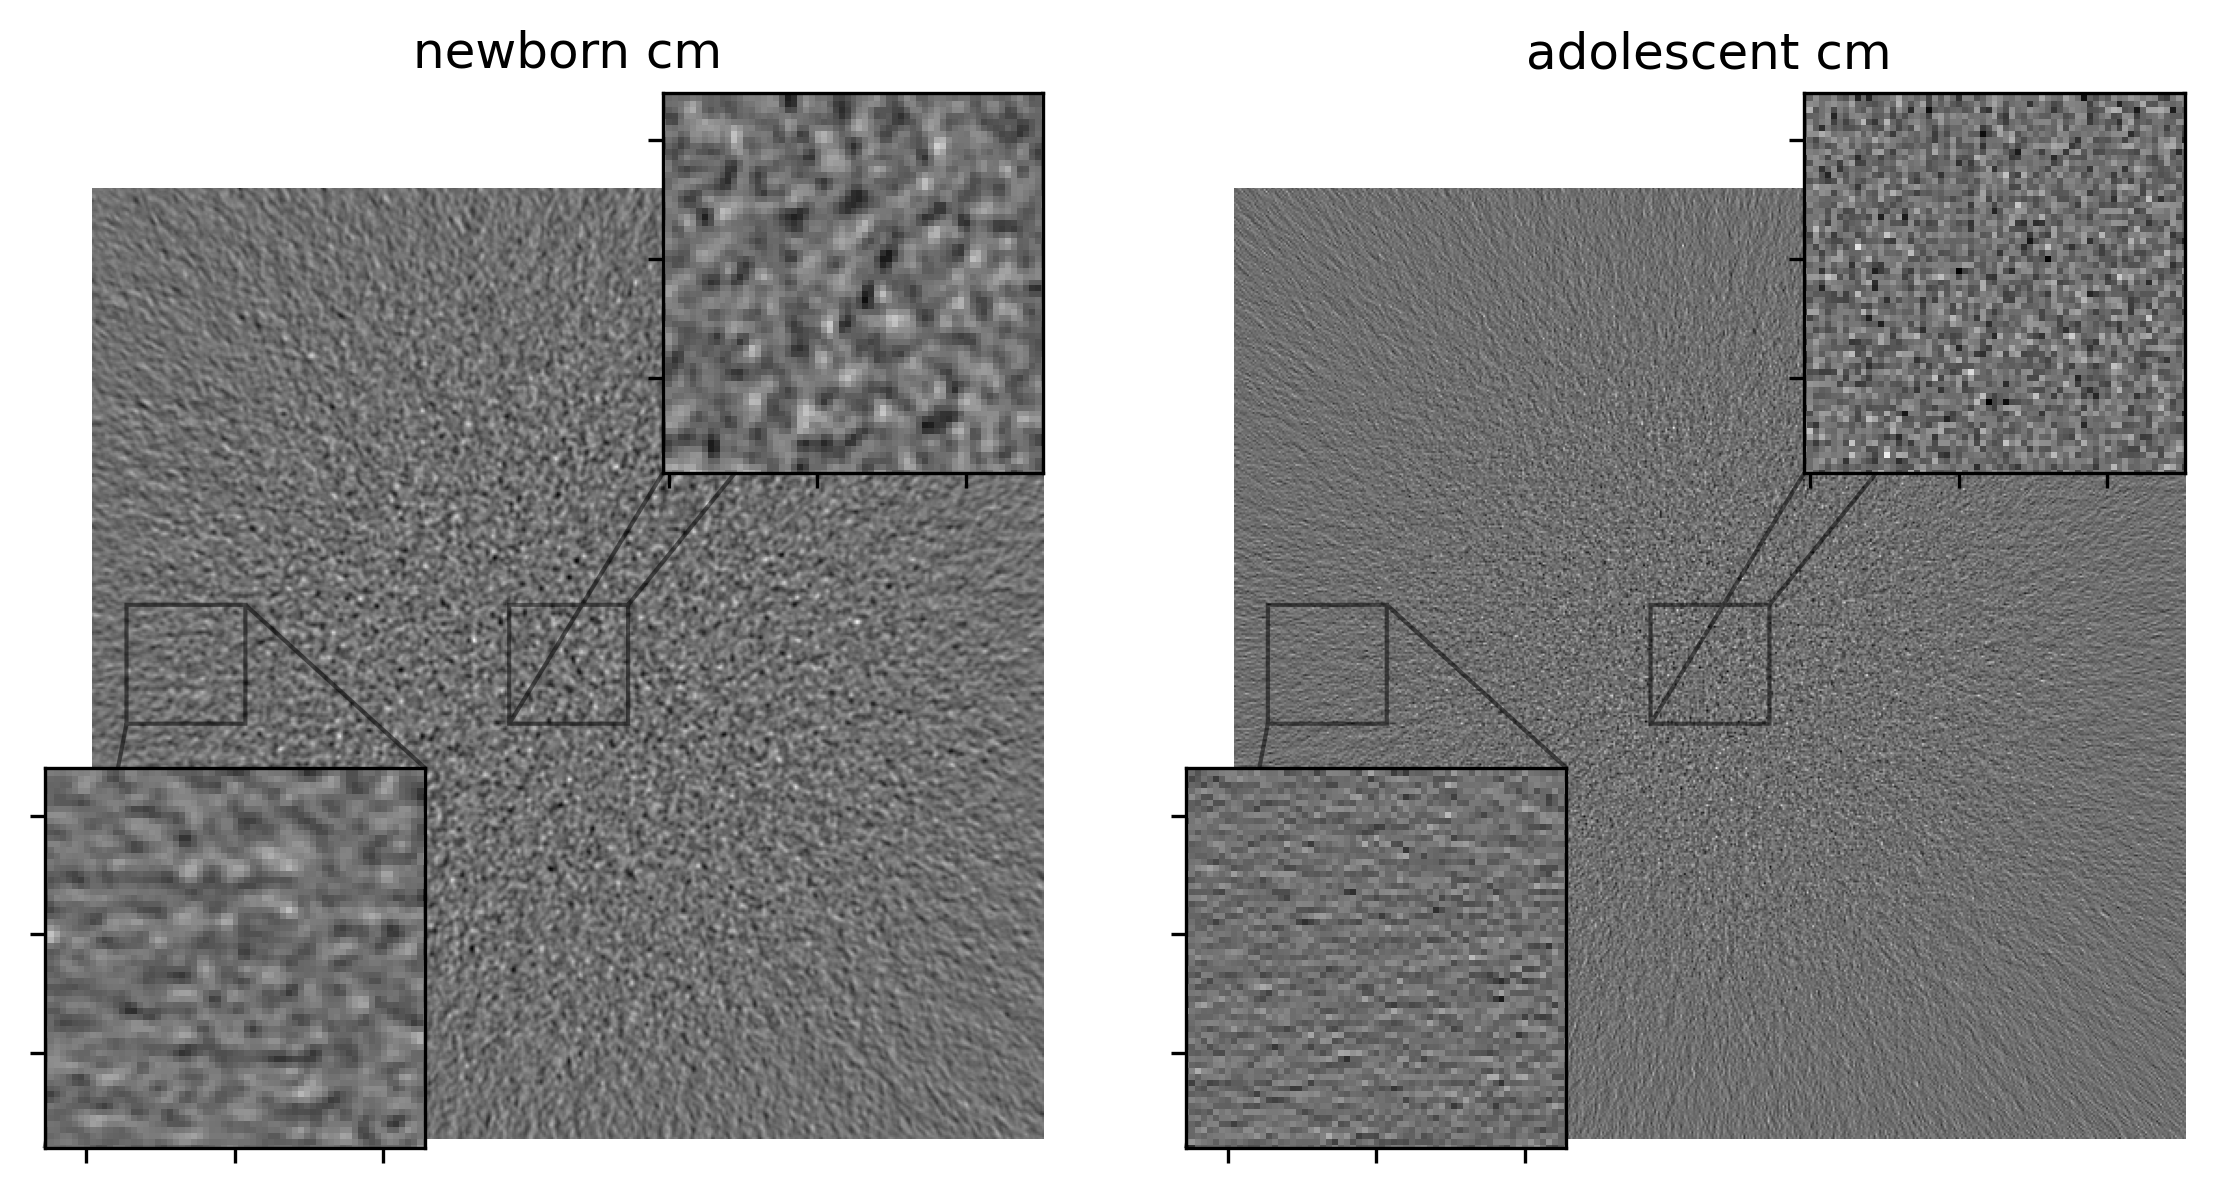

In [28]:
diams = ['newborn', 'adolescent']

f, axs = plt.subplots(1, len(diams), figsize=(9, 5), dpi=300)

for d, ax in zip(diams, axs.flatten()):
    noise_image = noise_image_dict[d][0]
    ax.imshow(noise_image, cmap='gray')

    # inset axes....
    axins_center = ax.inset_axes(
        [0.6, 0.7, 0.4, 0.4],
        xlim=(corners[0][0] - patch_size//2, corners[0][0] + patch_size//2), ylim=(corners[0][1] - patch_size//2, corners[0][1] + patch_size//2), xticklabels=[], yticklabels=[])
    axins_center.imshow(noise_image, cmap='gray')

    ax.indicate_inset_zoom(axins_center, edgecolor="black")

    axins_left = ax.inset_axes(
        [-0.05, -0.01, 0.4, 0.4],
        xlim=(corners[1][0] - patch_size//2, corners[1][0] + patch_size//2), ylim=(corners[1][1] - patch_size//2, corners[1][1] + patch_size//2), xticklabels=[], yticklabels=[])
    axins_left.imshow(noise_image, cmap='gray')

    ax.indicate_inset_zoom(axins_left, edgecolor="black")
    ax.axis('off')
    ax.set_title(f'{d} cm')

In [32]:
anthro_meta = pd.read_csv(anthro_datadir / 'metadata.csv')
anthro_meta = anthro_meta[anthro_meta.phantom == 'anthropomorphic']
# anthro_meta.file = anthro_meta.file.apply(lambda o: Path(anthro_datadir).parent / o.split('../data/')[1])
anthro_meta.loc[anthro_meta.file.apply(lambda o: Path(o).stem.endswith('noisefree')), 'series'] = 'noise free'
anthro_meta

,Code #,Name,age [year],gender,weight [kg],height [cm],BMI,weight percentile,ethnicity,effective diameter [cm],Dose [%],recon,phantom,file,simulated,FOV [cm],kernel,scanner,instance,series
0,Reference newborn,male infant,0.166,M,3.8,52.0,14.100000,36.0,NaN,11.1,25,fbp,anthropomorphic,male_infant/diameter_111mm/dose_025/fbp/male_i...,True,14.43,D45,Siemens Definition AS+ (simulated),0,NaN
1,Reference newborn,male infant,0.166,M,3.8,52.0,14.100000,36.0,NaN,11.1,25,fbp,anthropomorphic,male_infant/diameter_111mm/dose_025/fbp/male_i...,True,14.43,D45,Siemens Definition AS+ (simulated),1,NaN
2,Reference newborn,male infant,0.166,M,3.8,52.0,14.100000,36.0,NaN,11.1,25,fbp,anthropomorphic,male_infant/diameter_111mm/dose_025/fbp/male_i...,True,14.43,D45,Siemens Definition AS+ (simulated),2,NaN
3,Reference newborn,male infant,0.166,M,3.8,52.0,14.100000,36.0,NaN,11.1,25,fbp,anthropomorphic,male_infant/diameter_111mm/dose_025/fbp/male_i...,True,14.43,D45,Siemens Definition AS+ (simulated),3,NaN
4,Reference newborn,male infant,0.166,M,3.8,52.0,14.100000,36.0,NaN,11.1,25,fbp,anthropomorphic,male_infant/diameter_111mm/dose_025/fbp/male_i...,True,14.43,D45,Siemens Definition AS+ (simulated),4,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,151,female pt151,66.000,F,66.4,162.0,25.301021,48.8,white,28.1,100,fbp,anthropomorphic,female_pt151/diameter_281mm/dose_100/fbp/femal...,True,36.53,D45,Siemens Definition AS+ (simulated),5,NaN
396,151,female pt151,66.000,F,66.4,162.0,25.301021,48.8,white,28.1,100,fbp,anthropomorphic,female_pt151/diameter_281mm/dose_100/fbp/femal...,True,36.53,D45,Siemens Definition AS+ (simulated),6,NaN
397,151,female pt151,66.000,F,66.4,162.0,25.301021,48.8,white,28.1,100,fbp,anthropomorphic,female_pt151/diameter_281mm/dose_100/fbp/femal...,True,36.53,D45,Siemens Definition AS+ (simulated),7,NaN
398,151,female pt151,66.000,F,66.4,162.0,25.301021,48.8,white,28.1,100,fbp,anthropomorphic,female_pt151/diameter_281mm/dose_100/fbp/femal...,True,36.53,D45,Siemens Definition AS+ (simulated),8,NaN


In [ ]:
vol = np.stack([load_img(o) for o in anthro_meta[
                (anthro_meta['effective diameter [cm]']==11.2) &
                (anthro_meta['Dose [%]'] == 25) &
                (anthro_meta['series'] == 'simulation') &
                (anthro_meta['recon'] == 'fbp')].file])
vol.shape

In [36]:
import sys
from nps_utils import compute_nps, radial_profile
from make_noise_patches import make_noise_images

patient_noise_images = make_noise_images(vol)
patient_nps = compute_nps(patient_noise_images)

/home/brandon.nelson/Dev/pediatric-CT-noise-texture-augmentation/notebooks/nps_utils.py:63: SyntaxWarning: invalid escape sequence '\D'
  col_name = f'$\Delta$ {measurement}'


NameError: name 'vol' is not defined

In [ ]:
from utils import pediatric_subgroup
anthro_meta['pediatric subgroup'] = anthro_meta['effective diameter [cm]'].apply(pediatric_subgroup)

In [ ]:
for subgroup in anthro_meta['pediatric subgroup'].unique():
    print(f"{subgroup}: {len(anthro_meta[anthro_meta['pediatric subgroup']==subgroup].Name.unique())} patients")

In [ ]:
import seaborn as sns
sns.histplot(data=anthro_meta, x='pediatric subgroup')

In [ ]:
anthro_meta[(anthro_meta['pediatric subgroup']=='newborn') & (anthro_meta['Dose [%]'] == 25) & (anthro_meta['recon'] == 'fbp')]

Let's look at all of the images first

In [ ]:
patient_images = []
annotations = []
for subgroup in anthro_meta['pediatric subgroup'].unique():
    for idx, patient in enumerate(anthro_meta[anthro_meta['pediatric subgroup']==subgroup].Name.unique()):
        vol = np.stack([load_img(o) for o in anthro_meta[(anthro_meta.Name==patient) & (anthro_meta['Dose [%]'] == 25) & (anthro_meta['recon'] == 'fbp')].file])
        patient_images.append(vol[0])
        annotations.append(subgroup)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
nrows = 5
ncols = 4
f, ax = plt.subplots(dpi=300, figsize=(10,8))
ax.imshow(np.concatenate([np.concatenate([patient_images[i+j*i] for i in range(ncols)], axis=1) for j in range(nrows)], axis=0), cmap='gray', vmin=-250, vmax=300)
ax.axis('off')
[[ax.annotate(annotations[j+i*nrows], (100+i*512, 80+j*512), color='white', fontsize=12) for i in range(ncols)] for j in range(nrows)]
plt.show()

In [ ]:
sub_group_noise_dict = dict()
for subgroup in anthro_meta['pediatric subgroup'].unique():
    print(f"{subgroup}: {len(anthro_meta[anthro_meta['pediatric subgroup']==subgroup].Name.unique())} patients")
    subgroup_noise_images = []
    for patient in anthro_meta[anthro_meta['pediatric subgroup']==subgroup].Name.unique():
        vol = np.stack([load_img(o) for o in anthro_meta[(anthro_meta.Name==patient) & (anthro_meta['Dose [%]'] == 25) & (anthro_meta['recon'] == 'fbp') & (anthro_meta['series'] == 'simulation')].file])
        subgroup_noise_images.append(make_noise_images(vol))
    sub_group_noise_dict[subgroup] = np.array(subgroup_noise_images)

In [ ]:
f, axs = plt.subplots(2, 3, figsize=(6,4), dpi=150)
axs = axs.flatten()
groups = []
nps_1d = []
subgroups = anthro_meta['pediatric subgroup'].unique()
for subgroup, ax in zip(subgroups, axs):
    nps = compute_nps(sub_group_noise_dict[subgroup].reshape(-1, 512, 512))
    nps_profile = radial_profile(nps)
    groups.append(subgroup)
    nps_1d.append(nps_profile)
    ax.imshow(nps)
    ax.axis('off')
    ax.set_title(f'{subgroup} nps')
pd.DataFrame(data=np.array(nps_1d).T, columns=groups).plot(ax=axs[-1])

## Noise Texture from Pediatric-Sized Water Phantom Simulations

Noise statistically can be described in terms of its intensity content and its spatial content.

- Intensity content can be described using histograms to describe the distribution of pixel intensities that can be summarized by a mean (ideally around 0) and standard deviation, which describes the noise magnitude.
- Spatial content can be described using noise power spectra which uses Fourier analysis to quantify how much noise content exists at different spatial frequencies, where white noise (aka uncorrelated noise) is uniform across all frequencies, whereas more common in CT, noise is related to the spatial resolution of the system and thus is correlated leading to lower frequency peak that attenuates at higher frequencies due to the apodizing filter used in CT reconstruction (Cite links to learn more).

## Noise Properties of the Training Dataset

Before studying the noise in the out-of-distribution pediatric patients, we first want to establish a baseline of the noise properties used to train the deep denoiser, here trained on the [Mayo Clinic Low Dose Grand Challenge Dataset](https://aapm.onlinelibrary.wiley.com/doi/full/10.1002/mp.12345)

In [ ]:
idx = 9
f = plt.figure(figsize=(6,3), dpi=150)
ax = plt.subplot(1,2,1)
im = ax.imshow(x[0, idx], cmap='gray')
plt.title('input')
plt.colorbar(im)
ax = plt.subplot(1,2, 2)
im = ax.imshow(y[0, idx], cmap='gray')
plt.colorbar(im)
plt.title('target')
plt.tight_layout()

### See how the training data histograms compare to the processed training data files and test data

First load the test images (low dose inputs and routine dose targets)

In [ ]:
img_path = ldgc_path / 'images'
raw_images = list((img_path/'L506').rglob('*.IMA')) #L506 the test case

test_input_dcms = [f for f in raw_images if 'quarter_3mm' in str(f)]
test_target_dcms = [f for f in raw_images if f not in test_input_dcms]
test_input_dcms.sort()
test_target_dcms.sort()

import pydicom
import numpy as np

test_inputs = []
for fname in test_input_dcms:
  dcm_file = pydicom.read_file(fname)
  test_inputs.append(dcm_file.pixel_array.astype('float32') + float(dcm_file.RescaleIntercept))
test_inputs = np.array(test_inputs)

test_targets = []
for fname in test_target_dcms:
  dcm_file = pydicom.read_file(fname)
  test_targets.append(dcm_file.pixel_array.astype('float32') + float(dcm_file.RescaleIntercept))
test_targets= np.array(test_targets)

### Look at all of the training pairs in a batch

In [ ]:
from PIL import Image
from utils import pil_grid, normalize

In [ ]:
y.reshape(-1, 64, 64).numpy().shape

In [ ]:
print('All training pairs for a single batch shown below as follows:')
print('routine dose (top) `y`')
print('------------------')
print('low dose (bottom) `x`')
l_images = []
grid_size = 17
N = grid_size**2
for i in range(N):
    image = (normalize(np.concatenate([y.reshape(-1, 64, 64).numpy()[i], x.reshape(-1, 64, 64).numpy()[i]], axis=0))*255).astype('uint8')
    l_images.append(Image.fromarray(image))
pil_grid(l_images, grid_size)

learly the patietnt table was in a lot fof the traini exampsles..

In [ ]:
train_noise = x - y
test_noise = test_targets - test_inputs

In [ ]:
x.dtype, y.dtype, train_noise.dtype

Just training

### Pixel Instensity Distribution

In [ ]:
f, axs = plt.subplots(1,1, dpi=150, figsize=(6,4))
axs.hist([x.ravel(), y.ravel(), train_noise.ravel()], label = ['train input [x]', 'train target [y]', 'train noise = x - y'], bins=4096, density=True, histtype='step', alpha=0.65)
axs.legend()
axs.set_ylim([0, 0.01])
axs.set_xlim([-1024, 1000])
axs.set_xlabel('CT Number [HU]')
axs.set_ylabel('Frequency')

In [ ]:
f, axs = plt.subplots(1,2, dpi=150, figsize=(8,4), sharex=True, sharey=True)
axs[0].hist([x.ravel(), y.ravel(), test_inputs.ravel(), test_targets.ravel()], label = ['train input [x]', 'train target [y]', 'test input [x]', 'test target [y]'], bins=4096, density=True, histtype='step')
axs[0].legend()
axs[0].set_ylim([0, 0.01])
axs[0].set_xlim([-1024, 1000])
axs[0].set_xlabel('CT Number [HU]')
axs[0].set_ylabel('Frequency')
axs[1].hist([train_noise.ravel(), test_noise.ravel()], label = ['train noise = x - y', 'test noise = x - y'], bins=4096, density=True, histtype='step')
axs[1].legend()
axs[1].set_ylim([0, 0.01])
axs[1].set_xlim([-1024, 1000])
axs[1].set_xlabel('CT Number [HU]')
axs[1].annotate(f'test (mean | std):\n({test_noise.mean():2.2f} | {test_noise.std():2.2f})\ntrain (mean | std):\n({train_noise.numpy().mean():2.2f} | {train_noise.numpy().std():2.2f})', (-900, 0.005), fontsize=8)

^ This confirms that there was no scaling done to the training data

### Now what does the noise histograms look like and how does this compare to our noise patches? 
Note: Two sets of images amay have the sae histogram statistics but wildly different textures (give exmaple of this, because histograms have no spatial awareness, whereas NPS does)

In [ ]:
noise_patch_dir = Path('/home/brandon.nelson/Dev/PediatricCTSizeAugmentation/noise_patches/patch_size_64x64')
diameters = [112, 131, 151, 185, 216, 292]

noise_files = [noise_patch_dir / f'diameter{d}mm.npy' for d in diameters]
noise_patch_dict = {f.stem: np.load(f)[:100] for f in noise_files}
noise_patches = np.concatenate(list(noise_patch_dict.values()))

In [ ]:
peds_datadir

In [ ]:
!ls ../data/pediatricIQphantoms/

In [ ]:
from make_noise_patches import prep_patches
patch_size = (64, 64)
noise_patch_dict = prep_patches(meta, patch_size=patch_size, dose=25, max_images=100)

In [ ]:
noise_diam = np.load(noise_patch_dir / 'diameter292mm.npy')
noise_diam.shape

In [ ]:
f, axs = plt.subplots(1,1, dpi=150, figsize=(6,4))
axs.hist([noise_patch_dict[o].ravel() for o in sorted(noise_patch_dict.keys(), reverse=True)], bins=4096, label=sorted(list(noise_patch_dict.keys()), reverse=True),
         density=True, histtype='step', alpha=0.65)
axs.legend(title='phantom diameter [mm]')
axs.set_xlabel('CT Number [HU]')
axs.set_ylabel('Frequency')
axs.set_title('Phantom Noise Intensity Histograms')
axs.annotate('AEC noise magnitude:\n28 HU', (-150, 0.125))

In [ ]:
plt.hist([x.ravel(), y.ravel(), test_inputs.ravel(), train_noise.ravel(), noise_patch_dict[29.2].ravel()], label = ['low dose input [x]', 'routine dose target [y]', 'test patient inputs [x]', 'train noise image`: x - y', 'phantom noise patches'], bins=4096, density=True, histtype='step')
plt.legend()
plt.ylim([0, 0.01])
plt.xlim([-1024, 1000])
plt.show()

In [ ]:
normalized_patches = {d: noise_patch_dict[d]/noise_patch_dict[d].std()*train_noise.numpy().std() for d in noise_patch_dict}
# normalized_patches = {d: noise_patch_dict[d]/np.sqrt(2) for d in noise_patch_dict}

In [ ]:
plt.hist([train_noise.ravel(), noise_patch_dict[29.2].ravel(), normalized_patches[29.2].ravel()], label = ['train noise =  x - y', 'phantom noise patches', 'renormalized noise patches'], bins=4096, density=True, histtype='step')
plt.legend()
plt.show()

In [ ]:
train_noise.shape

In [ ]:
train_noise.numpy().mean(axis=(0, 1)).shape

In [ ]:
normalized_patches[29.2].std(), train_noise.numpy().std()

In [ ]:
noise_patch_dict[29.2].shape, train_noise.reshape(-1, 64, 64, 1).shape

In [ ]:
from skimage.exposure import match_histograms, histogram

input_shape = noise_patch_dict[29.2].shape

input_images = noise_patch_dict[29.2].reshape(-1, 1)
ref_images = train_noise.reshape(-1, 1).numpy()

print(input_images.shape, ref_images.shape)

equal_hist_patches = {diam: match_histograms(input_images.reshape(-1, 1), reference=ref_images).reshape(input_shape) for diam, input_images in noise_patch_dict.items()}
[o.shape for o in equal_hist_patches.values()]

In [ ]:
import pandas as pd

def summarize_patches(patch_dicts:list, names:list):
    rows = list(sorted(patch_dicts[0].keys()))
    for measure, measure_name in zip([lambda x: x.mean(), lambda x: x.std()], ['mean', 'std']):
        temp_names = [o + " " + measure_name for o in names]
        if measure_name == 'mean':
            anthro_meta = pd.DataFrame(data=np.array([[patches[o].mean() for o in rows] for patches in patch_dicts]).T, index=rows, columns=temp_names)
        else:
            anthro_meta = anthro_meta.join(pd.DataFrame(data=np.array([[patches[o].std() for o in rows] for patches in patch_dicts]).T, index=rows, columns=temp_names))
    anthro_meta['training noise mean'] = train_noise.numpy().mean()
    anthro_meta['training noise std'] = train_noise.numpy().std()
    return anthro_meta

summarize_patches([noise_patch_dict, normalized_patches, equal_hist_patches], ['Original', 'normalized','hist matched'])

1. It's interesting that a DC component was added in the histogram matching so we remove it and check again.

In [ ]:
equal_hist_patches = {diam: match_histograms(input_images.reshape(-1, 1), reference=ref_images).reshape(input_shape) for diam, input_images in noise_patch_dict.items()}
equal_hist_patches = {diam: p - p.mean() for diam, p in equal_hist_patches.items()}

summarize_patches([noise_patch_dict, normalized_patches, equal_hist_patches], ['Original', 'normalized','hist matched'])

Now we see that the hist matched mean is 0 and has a standard deviation matching the training noise

In [ ]:
plt.hist([train_noise.ravel(), noise_patch_dict[29.2].ravel(), equal_hist_patches[29.2].ravel()], label = ['`noise image`: x - y', 'noise patches', 'matched hist noise patches'], bins=4096, density=True, histtype='step')
plt.legend()
plt.show()

In [ ]:
from skimage.exposure import cumulative_distribution

In [ ]:
def gaussian(img_hist, sigma=3):
    x = np.arange((len(img_hist)))
    return np.exp(-np.power(x-len(img_hist)//2,2)/sigma**2)

# plt.plot(gaussian(img_hist, 11))

In [ ]:
smooth = True
for img, lbl, style in zip([train_noise.numpy(), noise_patch_dict[29.2], equal_hist_patches[29.2]],
                           ['training dataset noise`: x - y', 'phantom scan noise patches', 'histogram matched phantom noise patches'],
                           ['red', 'green', 'blue']):
    img = img.astype('int16')
    img_hist, hbins = histogram(img)
    if smooth: img_hist = np.convolve(img_hist, gaussian(img_hist, 11), mode='same')
    plt.plot(hbins, img_hist/ img_hist.max(), color=style, label=lbl)
plt.xlim([-200, 200])
plt.legend()
plt.show()

In [ ]:
for img, lbl, style in zip([train_noise.numpy(), np.array(list(noise_patch_dict.values())).ravel(), np.array(list(equal_hist_patches.values())).ravel()],
                           ['training dataset noise`: x - y', 'phantom scan noise patches', 'histogram matched phantom noise patches'],
                           ['red', 'green', 'blue']):
    img = img.astype('int16')
    img_hist, hbins = histogram(img)
    plt.plot(hbins, img_hist/ img_hist.max(), color=style, label=lbl)
plt.xlim([-200, 200])
plt.legend()
plt.show()

Due to histogram matching there are now gaps in the histogram due to spreading the intensity values around, so let's apply a smoothing to the histogram for visualization purposes

In [ ]:
np.array(list(noise_patch_dict.values())).ravel()

## Figure 2.d

In [ ]:
smooth = True
f, ax = plt.subplots(figsize=(4,3.5), dpi=300)
for img, lbl, style in zip([train_noise.numpy(), np.array(list(noise_patch_dict.values())).ravel(), np.array(list(equal_hist_patches.values())).ravel()],
                           ['training dataset', 'phantom data', 'histogram matched phantom data'],
                           ['-', '--', ':']):
    img = img.astype('int16')
    img_hist, hbins = histogram(img, normalize=True)
    if smooth: img_hist = np.convolve(img_hist, gaussian(img_hist, 11), mode='same')
    ax.plot(hbins, img_hist, label=lbl, linestyle=style)
ax.set_title('Noise Image Pixel Intensity Distribution')
ax.set_ylabel('frequency')
ax.set_xlabel('difference image CT number [HU]')
ax.set_xlim([-200, 200])
ax.set_ylim([0, 0.23])
ax.legend()
f.show()

In [ ]:
print(train_noise.numpy().mean(), train_noise.numpy().std())

[equal_hist_patches[d].std() for d in equal_hist_patches]

In [ ]:
[o.std() for o in noise_patch_dict.values()]

In [ ]:
print('original noise patches')
[print(f'{k} mean {v.mean():2.3f} | std {v.std():2.3f}') for k,v in noise_patch_dict.items()]
print('hist equalized noise patches')
[print(f'{k} mean {v.mean():2.3f} | std {v.std():2.3f}') for k,v in equal_hist_patches.items()];

Nwxt look at the noise patches in trhe training set to understand the difference in hist (higher rorder)

In [ ]:
print('All training noise:')
l_images = []
grid_size = 6
N = grid_size**2
for i in range(N):
    image = (normalize(np.concatenate([train_noise.reshape(-1, 64, 64).numpy()[i]], axis=0))*255).astype('uint8')
    l_images.append(Image.fromarray(image))
pil_grid(l_images, grid_size)

In [ ]:
print('All generated noise patches:')
l_images = []
grid_size = len(noise_patch_dict)
N = grid_size**2
for diam in noise_patch_dict:
    print(diam)
    for i in range(grid_size):
        image = (normalize(np.concatenate([noise_patch_dict[diam][i]], axis=0))*255).astype('uint8')
        l_images.append(Image.fromarray(image))
pil_grid(l_images, grid_size)

In [ ]:
print('Histogram matched noise patches:')
l_images = []
grid_size = len(noise_patch_dict)
N = grid_size**2
for diam in noise_patch_dict:
    print(diam)
    for i in range(grid_size):
        image = (normalize(np.concatenate([equal_hist_patches[diam][i]], axis=0))*255).astype('uint8')
        l_images.append(Image.fromarray(image))
pil_grid(l_images, grid_size)

As we saw above these nmoise patches look quite differ ent by row but all have the same histogram

Now look at the frequency components 

In [ ]:
def compute_nps(image):

  if image.ndim == 2:
    image = image[None, :, :]

  if image.ndim == 4:
    image = image[:,:,:,0]

  nsize = image.shape
  nrealization = nsize[0]
  if image.ndim == 3:
    nps = np.zeros((nsize[1],nsize[2]))
    for i in range(nrealization):
      s = np.fft.fftshift(np.fft.fft2(image[i]))
      nps = np.abs(s)**2 + nps
    nps = nps/(nsize[1]*nsize[2])
  else:
    raise ValueError(f'Image of dimension {image.ndim} Not implemented!')
  return nps


def radial_profile(data, center=None):
    center = center or (data.shape[0]/2, data.shape[1]/2)
    y, x = np.indices((data.shape))
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    r = r.astype(int)

    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())
    radialprofile = tbin / nr
    return radialprofile

nps = compute_nps(noise_patch_dict[29.2])
nps_1d = radial_profile(nps)

f, axs = plt.subplots(1,2)
axs[0].imshow(nps)
axs[1].plot(nps_1d)

In [ ]:
f, axs = plt.subplots(2, 3, sharex=True, sharey=True, figsize=(10, 5), dpi=150)
for d, ax in zip(diameters, axs.flatten()):
    patches = noise_patch_dict[d/10]
    nps = compute_nps(patches)
    ax.imshow(nps)
    ax.axis('off')
    ax.set_title(f'{len(patches)} x {d} mm patch\nstd: {patches.std():3.3f}')

In [ ]:
plt.imshow(train_noise.reshape(-1, 64, 64)[0], cmap='gray')

In [ ]:
np.array(train_noise).mean()

In [ ]:
train_nps=compute_nps(train_noise.reshape(-1, 64, 64)-np.array(train_noise).mean())
train_nps[(64//2-2):(64//2+3), (64//2-1):(64//2+1)]=0
# train_nps[0,:]=0
# train_nps[-1,:]=0
# train_nps[:,0]=0
# train_nps[:,-1]=0
train_nps_1d = radial_profile(train_nps)
plt.imshow(train_nps, cmap='gray')
plt.show()
plt.plot(train_nps_1d)
plt.show()

## Figure 2.e.

In [ ]:
smooth = True
f, ax = plt.subplots(figsize=(4,3.5), dpi=150)
train_nps_1d = radial_profile(train_nps)
nps_1d = train_nps_1d

if smooth: nps_1d = np.convolve(nps_1d, gaussian(nps_1d, 3), 'same')
nps_1d = nps_1d / nps_1d.max()

plt.plot(nps_1d, label='training dataset', linestyle='-')

for d, style in zip([11.2, 18.5, 29.2], ['--', ':', '-.']):
    patches = noise_patch_dict[d]
    nps = compute_nps(patches)
    nps_1d = radial_profile(nps)
    if smooth: nps_1d = np.convolve(nps_1d, gaussian(nps_1d, 3), 'same')
    nps_1d/=nps_1d.max()
    plt.plot(nps_1d, label=d, linestyle=style)

plt.ylabel('Noise Power [$HU^2$]')
plt.xlabel('Spatial Frequency [cycles/pixel]')
# plt.title('Phantom Noise') 
plt.legend(title='phantom diameter [mm]')
plt.savefig('figures/fig2e_nps_comparison.png', dpi=600)

In [ ]:
smooth = True
f, ax = plt.subplots(figsize=(4,3.5), dpi=150)
train_nps_1d = radial_profile(train_nps)
nps_1d = train_nps_1d

if smooth: nps_1d = np.convolve(nps_1d, gaussian(nps_1d, 3), 'same')
nps_1d = nps_1d / nps_1d.sum()

plt.plot(nps_1d, label='training dataset', linestyle='-')

for d, group, style in zip([11.2, 18.5, 29.2], ['newborn', 'child', 'adolescent'], ['--', ':', '-.']):
    patches = noise_patch_dict[d]
    nps = compute_nps(patches)
    nps_1d = radial_profile(nps)
    if smooth: nps_1d = np.convolve(nps_1d, gaussian(nps_1d, 3), 'same')
    nps_1d/=nps_1d.sum()
    plt.plot(nps_1d, label=f'{d} "{group}"', linestyle=style)

plt.ylabel('Normalized Noise Power [$HU^2$]')
plt.xlabel('Spatial Frequency [cycles/pixel]')
# plt.title('Phantom Noise') 
plt.legend(title='phantom diameter [cm]')
plt.show()

In [ ]:
noise_patch_dict.keys()

In [ ]:
for d in diameters[::2]:
    patches = noise_patch_dict[d/10]
    nps = compute_nps(patches)
    nps_1d = radial_profile(nps)
    plt.plot(nps_1d, label=f'{d} mm original')

    patches = equal_hist_patches[d/10]
    nps = compute_nps(patches)
    nps_1d = radial_profile(nps)
    plt.plot(nps_1d, label=f'{d} mm hist matched', marker='*', linestyle='')
plt.legend()
plt.show()

Histogram matching the noise patches for augmentated training to match the intensity distribution of the training set

A few things to note:
1. Since the noise magnitude has been increased, the height was increased, so to better compare, we'll look at the normalized NPS

In [ ]:
for d in diameters[::2]:
    patches = noise_patch_dict[d/10]
    nps = compute_nps(patches)
    nps /= nps.sum() # <--- here
    nps_1d = radial_profile(nps)
    plt.plot(nps_1d, label=f'{d} mm original')

    patches = equal_hist_patches[d/10].copy()
    nps = compute_nps(patches)
    nps /= nps.sum() # <--- and here
    nps_1d = radial_profile(nps)
    plt.plot(nps_1d, label=f'{d} mm hist matched', marker='*', linestyle='')
plt.legend()
plt.xlabel('Spatial Frequncy [cycles/pixel]')
plt.ylabel('Noise Power [$HU^2$]')
plt.show()

Add anthropomorphic phantoms as a different line style and overlay TODO: 4/4/2024

In [ ]:
from make_noise_patches import make_noise_patches

Need to add phantom scans to df data frame and assign pediatric subgroups to show that the phantom scans reproduce the noise textures of the pediatric anthro scans. Thus both noise texture and intensity are reproduced by these noise patches

In [ ]:
for group in sub_group_noise_dict:
    patient_noise_images = sub_group_noise_dict[group].reshape(-1, 512, 512)
    patches = make_noise_patches(patient_noise_images, patch_size=(64, 64))
    nps = compute_nps(patches)
    nps /= nps.sum() # <--- here
    nps_1d = radial_profile(nps)
    # plt.plot(nps_1d, label=f'{d} mm pediatric noise')

    patches = equal_hist_patches[d/10].copy()
    nps = compute_nps(patches)
    nps /= nps.sum() # <--- and here
    nps_1d = radial_profile(nps)
    plt.plot(nps_1d, label=f'{d} mm hist matched', marker='*', linestyle='')
plt.legend()
plt.xlabel('Spatial Frequncy [cycles/pixel]')
plt.ylabel('Noise Power [$HU^2$]')
plt.show()

After making these two adjustments, we can confirm that matching the histograms *did not alter the texture* 

^^ Now compare these 

In [ ]:
noise_patches = np.concatenate(list(equal_hist_patches.values()))

## Data Augmentation with Pediatric Protocol Noise Patches

In [ ]:
print('All training pairs for a single batch shown below as follows:')
print('routine dose (top) `y`')
print('------------------')
print('low dose (middle) `x`')
print('------------------')
print('noise augmented (bottom) `x`=y + noise_patch`')
l_images = []
grid_size = 17
N = grid_size**2
for i in range(N):
    noise_patch = noise_patches[np.random.choice(list(range(len(noise_patches))))]
    image = (normalize(np.concatenate([y.reshape(-1, 64, 64).numpy()[i], x.reshape(-1, 64, 64).numpy()[i], y.reshape(-1, 64, 64).numpy()[i]+noise_patch], axis=0))*255).astype('uint8')
    l_images.append(Image.fromarray(image))
pil_grid(l_images, grid_size)